In [1]:
import numpy as np
import matplotlib.pyplot as plt

## Gaussian Process

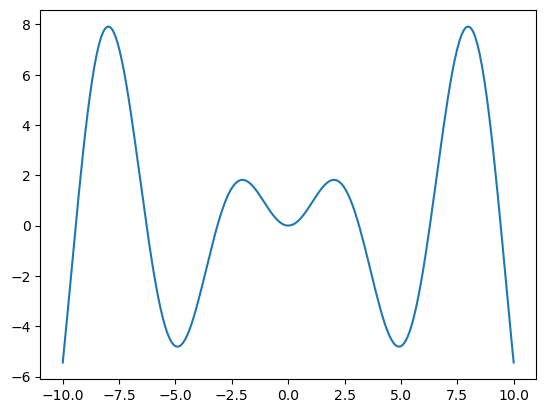

In [2]:
N = 200
x = np.linspace(-10, 10, N)
fx = x * np.sin(x)

plt.plot(x, fx)

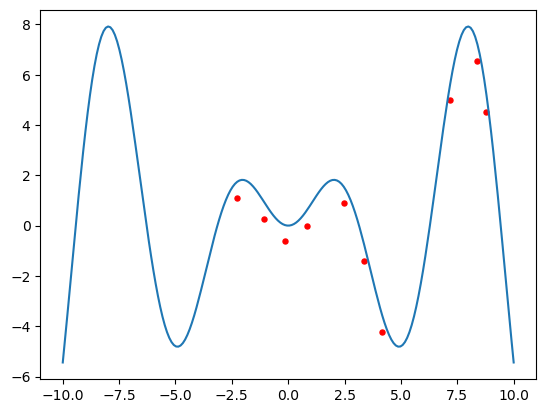

In [4]:
sample_size = 10
idx = np.random.randint(N, size=sample_size)

x_sample = x[idx]
fx_sample = fx[idx] + 1.8 * np.random.randn()

plt.plot(x, fx)
plt.scatter(x_sample, fx_sample, c='red', s=13)

$$
    RBF(\mathbf{x}_1, \mathbf{x}_2, \theta, \Theta) = \theta \exp\left( - \frac{1}{2} (\mathbf{x}_1 - \mathbf{x}_2)^T \Theta (\mathbf{x}_1 - \mathbf{x}_2)\right)
$$
where $\theta$ scales the output, and $\Theta$ is a diagonal matrix whose diagonal components $\Theta_{ii}$ control the length scale of the $i$-th Gaussian. 

In [5]:
def RBF(x1, x2, out_scale, len_scales):
    # x1, x2: shape (d, batch_size)
    return out_scale * np.exp(-0.5 * np.einsum('bi, ib -> bi', (x1 - x2).T, (np.diag(len_scales) @ (x1 - x2))))

x1 = np.array([1, 2]).reshape(1, -1)
x2 = np.array([4, 5]).reshape(1, -1)
RBF(x1, x2, 1, np.array([2]))

array([[0.00012341],
       [0.00012341]])

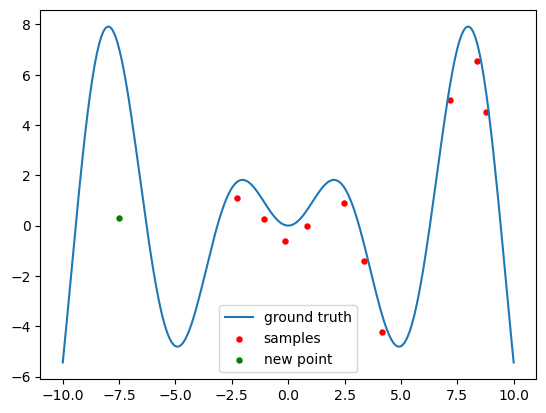

In [22]:
x0 = np.array([[-7.5]])

out_scale = 1
length_scales = np.array([2])

x_sample_reshaped = x_sample.reshape(1, -1)

k0 = RBF(x0, x_sample_reshaped, out_scale, length_scales)
k0k0 = RBF(x0, x0, out_scale, length_scales)

K = np.array([RBF(x_sample_reshaped[:, i], x_sample_reshaped, out_scale, length_scales) for i in range(sample_size)]).squeeze()
K_inv = np.linalg.pinv(K)

mu = k0.T @ K_inv @ fx_sample.reshape(-1, 1)
cov = k0k0 - k0.T @ K_inv @ k0

fx0 = np.random.normal(loc=mu, scale=cov)

plt.plot(x, fx, label="ground truth")
plt.scatter(x_sample, fx_sample, c='red', s=13, label="samples")
plt.scatter(x0, fx0, c='green', s=13, label="new point")
plt.legend()

In [23]:
def sample_function(x_sample, fx_sample, x_range, n):

    fx_range = []
    mu_range = []
    cov_range = []

    for x0 in x_range:
        x0 = x0.reshape(1, -1)

        out_scale = 1
        length_scales = np.array([2])

        x_sample_reshaped = x_sample.reshape(1, -1)

        k0 = RBF(x0, x_sample_reshaped, out_scale, length_scales)
        k0k0 = RBF(x0, x0, out_scale, length_scales)

        K = np.array([RBF(x_sample_reshaped[:, i], x_sample_reshaped, out_scale, length_scales) for i in range(sample_size)]).squeeze()
        K_inv = np.linalg.pinv(K)

        mu = k0.T @ K_inv @ fx_sample.reshape(-1, 1)
        cov = k0k0 - k0.T @ K_inv @ k0
        cov[np.where(cov < 0)] = 1e-4

        fx0 = np.random.normal(loc=mu, scale=cov, size=(n, 1))
        fx_range.append(fx0)
        mu_range.append(mu)
        cov_range.append(cov)

    return np.array(fx_range), np.array(mu_range), np.array(cov_range)

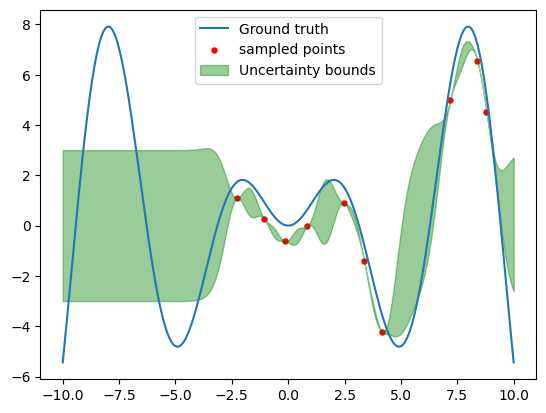

In [30]:
sampled_f, mu_vec, cov_vec = sample_function(x_sample, fx_sample, x, 1)

mu_vec = mu_vec[:, 0, 0]
cov_vec = cov_vec[:, 0, 0]

plt.plot(x, fx, label='Ground truth')
plt.scatter(x_sample, fx_sample, c='red', s=13, label='sampled points')
k = 3
plt.fill_between(x, mu_vec - k*cov_vec, mu_vec + k*cov_vec, color='green', alpha=0.4, label='Uncertainty bounds')
plt.legend()
plt.show()

In [31]:
def normal(x, mu, cov):
    return 1/(cov*2*np.pi + 1e-9)**0.5 * np.exp(-0.5 * (x-mu)**2/(cov + 1e-9))

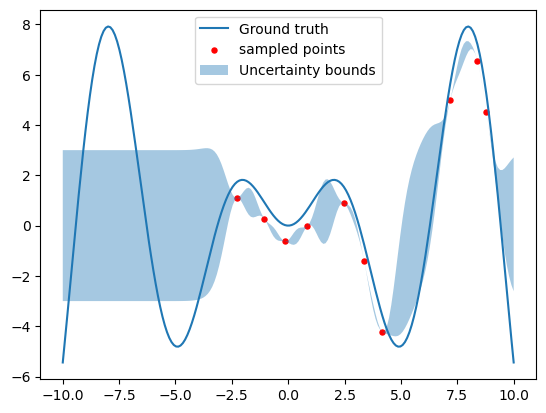

In [32]:
plt.plot(x, fx, label='Ground truth')
plt.scatter(x_sample, fx_sample, c='red', s=13, label='sampled points')
k = 3
plt.fill_between(x, mu_vec - 3*cov_vec, mu_vec + 3*cov_vec, cmap='coolwarm', alpha=0.4, label='Uncertainty bounds')
plt.legend()
plt.show()

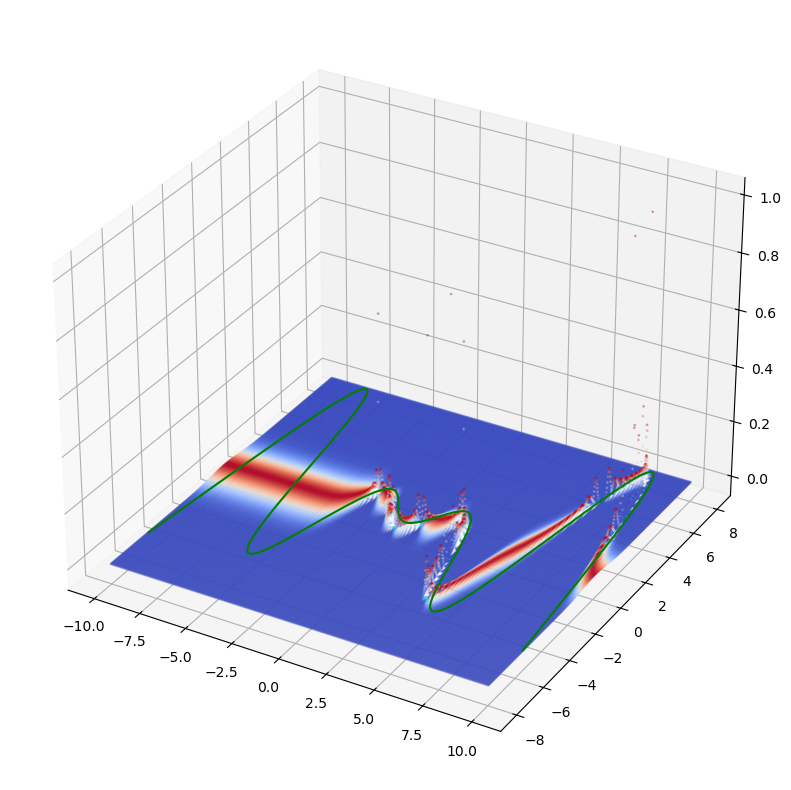

In [33]:
fig = plt.figure(figsize=(10, 10))
ax = fig.add_subplot(1, 1, 1, projection='3d', computed_zorder=False)

ax.plot(x, fx, label='Ground truth', color='green')
ax.scatter(x_sample, fx_sample, c='cyan', s=13, label='sampled points')

normal_range = np.linspace(-8, 8, 500)

for mu, cov, xi in zip(mu_vec, cov_vec, x):
    normal_values = normal(normal_range, mu, cov)
    normal_values = normal_values / (normal_values.sum(keepdims=True) + 1e-9)
    r = normal_values
    g = 0
    b = 1-r
    ax.scatter(np.ones_like(normal_range) * xi, normal_range, normal_values, alpha=0.3, c=normal_values, s=1, cmap='coolwarm')
    
# ax.view_init(25, 25)

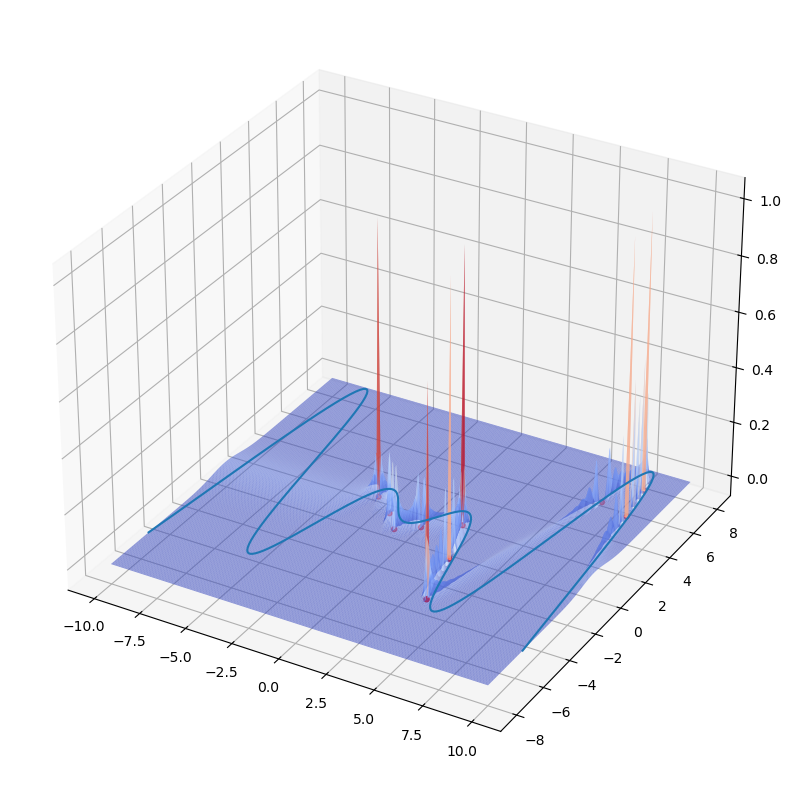

In [36]:
fig = plt.figure(figsize=(10, 10))
ax = fig.add_subplot(1, 1, 1, projection='3d', computed_zorder=False)

ax.plot(x, fx, label='Ground truth')
ax.scatter(x_sample, fx_sample, c='red', s=13, label='sampled points')

normal_range = np.linspace(-8, 8, 300)
w1_range = np.linspace(-8, 8, 300)
w2_range = np.linspace(-10, 10, 200)
w1_space, w2_space = np.meshgrid(w1_range, w2_range)

cols = np.array([normal(normal_range, mu, cov) for mu, cov in zip(mu_vec, cov_vec)])
cols = cols / (cols.sum(1, keepdims=True) + 1e-9)

ax.plot_surface(w2_space, w1_space, cols, cmap='coolwarm', alpha=0.6, rstride=1, cstride=1)

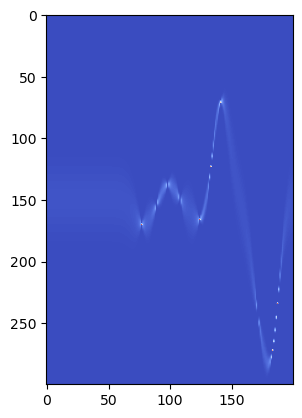

In [40]:
plt.imshow(cols.T, cmap='coolwarm')